In [32]:
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("Advertising.csv")

In [34]:
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [35]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [36]:
df[df.duplicated()]

,Unnamed: 0,TV,Radio,Newspaper,Sales


In [37]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [38]:
df = df.drop(columns =['Unnamed: 0'])

In [39]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [41]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Intercept (beta_0): 7.1196
Slope (beta_1): 0.0465
R-squared (R^2): 0.6767
Mean Squared Error (MSE): 10.2047
Regression Equation: Sales = 7.1196 + 0.0465 * TV


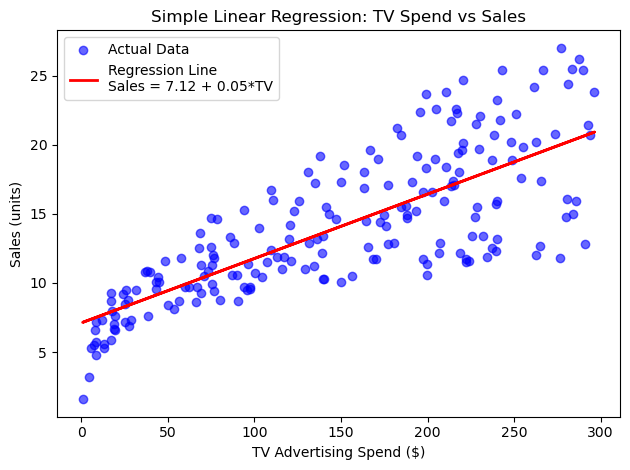

In [63]:
# 1. Reset X to ONLY the TV column (Simple Linear Regression)
X = df[["TV"]]
y = df["Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Retrain the model on just the one feature
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Calculate test predictions for your metrics
y_predict = model.predict(X_test)
intercept = model.intercept_
slope = model.coef_[0]
r2 = r2_score(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)

print(f"Intercept (beta_0): {intercept:.4f}")
print(f"Slope (beta_1): {slope:.4f}")
print(f"R-squared (R^2): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Regression Equation: Sales = {intercept:.4f} + {slope:.4f} * TV")

# 4. Plotting
plt.scatter(df["TV"], df["Sales"], color="blue", alpha=0.6, label="Actual Data")

# FIX: Predict inline for the entire df["TV"] column. 
# This works perfectly now because the model was only trained on "TV"
plt.plot(
    df["TV"],
    model.predict(df[["TV"]]),
    color="red",
    linewidth=2,
    label=f"Regression Line\nSales = {intercept:.2f} + {slope:.2f}*TV",
)

plt.xlabel("TV Advertising Spend ($)")
plt.ylabel("Sales (units)")
plt.title("Simple Linear Regression: TV Spend vs Sales")
plt.legend()
plt.tight_layout()

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error

In [65]:
X=df[["TV","Radio","Newspaper"]]
y=df["Sales"]

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)

In [67]:
model = LinearRegression()

In [68]:
model.fit(X_train,  y_train)

LinearRegression()

In [69]:
accuracy = model.score(X_test, y_test)
accuracy

0.899438024100912

In [70]:
y_predict = model.predict(X_test)

In [76]:
def sales_prediction():
    TV= float(input("Enter the investment on TV (in $): "))
    Radio = float(input("Enter the investment on Radio (in $): "))
    Newspaper = float(input("Enter the investment on Newspaper (in $): "))
    sales_input = pd.DataFrame([[TV, Radio, Newspaper]], columns=["TV","Radio","Newspaper"],)

    prediction = model.predict(sales_input)[0]
    print(f"Total unit of sales after investing on TV's, Radio's, Newspaper's is : {prediction:.2f} units")

sales_prediction()

Enter the investment on TV (in $):  150
Enter the investment on Radio (in $):  40
Enter the investment on Newspaper (in $):  20


Total unit of sales after investing on TV's, Radio's, Newspaper's is : 17.31 units


In [ ]:
import pickle
with open ("sales_prediction.pkl", "wb") as file:
    pickle.dump(model, file)
